## **Checklist do MVP**

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✔ |
| Dataset descrito, com fonte, atributos e restrições | ✔ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ✔ |
| Análise exploratória objetiva, conectada à modelagem | ✔ |
| Divisão adequada em treino/teste e, se aplicável, validação | ✔ |
| Prevenção de vazamento de dados | ✔ |
| Tratamentos de dados justificados | ✔ |
| Pipeline ou sequência reprodutível de pré-processamento | ✔ |
| Modelo baseline definido | ✔|
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ✔ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ✔ |
| Avaliação com métricas coerentes com o problema | ✔ |
| Discussão de overfitting/underfitting, limitações e melhorias | ✔ |
| Código limpo, organizado e executável do início ao fim | ✔|
| Conclusão conectada ao objetivo inicial | ✔ |


# 1. **Definição do problema**

## 1.1 Descrição do problema

O mercado de combustíveis apresenta variações ao longo do tempo influênciados por fatores econônomicos, operacionais e sazionais. Nesse contexto, a previsão da demanda pode auxiliar no planejamento e na tomada de decisão de empresas do setor.

**- Qual é o contexto do problema?**
Prever o volume mensal de vendas de Gasolina C e Etanol Hidratado no estado de Mato Grosso utilizando dados históricos da ANP.

**- Qual decisão, previsão, classificação, agrupamento ou análise o modelo deve apoiar?**
O modelo deve apoiar a previsão de demandas futuras de combustíveis, permitindo estimar os volumes de vendas para os meses seguintes a partir do comportamento histórico observado.

**- Quem seria o usuário ou interessado nessa solução?**
Os principais interessados seriam as empresas distribuidoras de combustíveis, áreas de planejamento, logística e área comercial, que necessitam estimar a demanda para apoiar em suas decisões operracionais.

**- Por que esse problema é relevante?**
A previsão de demanda pode contribuir para um planejamento mais eficiente das operações, auxiliando na gestão de estoques, transporte e distribuição de combustíveis, além de permitir uma melhor compreensão do comportamento de consumo ao longo prazo.



## 1.2 Objetivo do MVP

É desenvolver e comparar modelos de previsão para estimar demanda futura de combustíveis, avaliando sua capacidade de capturar padrões temporais presentes nos dados históricos e gerar previsões úteis para apoio na tomada de decisão.

**Objetivo deste trabalho:**  
>Construir e avaliar modelos de Machine Learnig para prever volumentria mensal de vendas de combustíveis, comparando uma abordagem baseline com modelos candidatos, avaliando suas limitações, resultados e possibilidades de melhorias.


## 1.3 Tipo de problema

**Tipo escolhido:** Séries Temporais (Forecasting)  
**Justificativa:** O projeto busca prever valores futuros de vendas utilizando observações históricas ao longo do tempo, preservando a seqência cronológica dos dados.




## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. O histórico de vendas contém padrões temporais que permitem estimar o comportamento futuro da demanda.
2. A utillização de variáveis derivadas do histórico, como defasagens e médias móveis, podem melhorar o desempenho do modelo.
3. Modelos de Machine Learning apresentam resultados superiores a uma abordagem baseline simples para a previsão dos volumes vendidos.

**Critérios de sucesso:**
- Métrica principal: MAE (Mean Absolute Error), por medir diretamente o erro médio das previsões em relação aos valores observados.

- Resultado mínimo esperado: Obter um desempenho superior ao modelo baseline, demonstrando que os modelos de Machobe Learnig conseguem capturar padrões temporais relevantes.

- Restrição prática: Utilizar modelos de fácil implementação e execução em ambiente Google Colab, mantendo a capacidade preditiva e baixo custo computacional.



# 2. Ambiente, bibliotecas e reprodutibilidade

Foram utilizadas bibliotecas para manipulação de dados, visualização gráfica, treinamento e avaliação de modelos de Machine Learning. Para garantir a reprodutibilidade dos resultados, foi definida uma semente aleatória fixa (SEED = 42), utilizada ao longo do projeto.


In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import GridSearchCV

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Métricas
from sklearn.metrics import (
 mean_absolute_error,
 mean_squared_error,
 mean_absolute_percentage_error
)

# Configurações
import warnings
warnings.filterwarnings('ignore')

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)


## 2.1 Dependências adicionais

Não foi necessária a instalação de dependências adicionais. Todas as bibliotecas utilizadas no projeto estão disponíveis nativamente no ambiente Google Colab.


**# MVP — Machine Learning & Analytics**

Nome: Bruna Roedel Carvalho

Matrícula:40530010056_20260_01

Dataset: Bases da ANP sobre comercialização de combustíveis líquidos e entregas por distribuidor, filtradas para o estado de Mato Grosso.

Fonte: https://www.gov.br/anp/pt-br/centrais-de-conteudo/paineis-dinamicos-da-anp/paineis-dinamicos-do-abastecimento/painel-dinamico-do-mercado-brasileiro-de-combustiveis-liquidos

Arquivos:  
* liquidos_vendas_atual.csv – utilizado para análise temporal e construção dos modelos preditivos.
* liquidos_entregas_distribuidor_atual.csv – utilizado para análises exploratórias complementares dos distribuidores.

**Tipo de problema:** Séries temporais (forecasting) para previsão do volume mensal de vendas de Gasolina C e Etanol Hidratado, utilizando modelos supervisionados de regressão.

**Data:** 27/06/2026

---




## 2.2 Funções auxiliares PENDENTE DE AVALIAÇÃO

Não foram criadas funções auxiliares específicas para este projeto. As métricas e etapas de modelagem foram implementadas diretamente ao longo do notebook, priorizando simplicidade e transparência da execução.

**# 3. Seleção e carga dos dados**

## 3.1 Fonte dos dados

Foram utilizadas duas bases públicas disponibilizadas pela Agência Nacional do Petróleo, Gás Natural e Biocombustíveis (ANP): a base de comercialização de combustíveis líquidos e a base de entregas por distribuidor.

As bases utilizadas foram adaptadas para hospedagem no GitHub, preservando apenas as informações necessárias ao desenvolvimento deste MVP.

**O que incluir:**
- nome do dataset: Bases da ANP sobre comercialização de combustíveis líquidos e entregas por distribuidor, filtradas para o estado de Mato Grosso.

- link da fonte:  https://www.gov.br/anp/pt-br/centrais-de-conteudo/paineis-dinamicos-da-anp/paineis-dinamicos-do-abastecimento/painel-dinamico-do-mercado-brasileiro-de-combustiveis-liquidos

- por que esse dataset foi escolhido: O dataset foi escolhido por disponibilizar dados públicos e históricos sobre o mercado brasileiro de combustíveis, permitindo a construção de modelos de previsão de demanda. A escolha também está alinhada à minha área de atuação profissional, contribuindo para uma análise mais contextualizada e aderente a desafios reais do setor.

- quais restrições ou condições foram consideradas: Foram considerados apenas os registros referentes ao estado de Mato Grosso e aos produtos Gasolina C e Etanol Hidratado. Além disso, foram utilizadas somente as variáveis necessárias para a análise exploratória e modelagem.

- se há questões de ética, privacidade, confidencialidade ou licença.
Não. Os dados são públicos, disponibilizados pela Agência Nacional do Petróleo, Gás Natural e Biocombustíveis (ANP), e não contêm informações pessoais ou sensíveis.









## 3.2 Carga dos dados

As bases foram disponibilizadas em repositório público no GitHub e carregadas diretamente no notebook por meio de URLs públicas, garantindo a reprodutibilidade do projeto sem necessidade de upload manual de arquivos.

In [2]:

# Base de vendas
url_vendas = "https://raw.githubusercontent.com/roedelbruna/ciencia_de_dados_-analytics-/main/liquidos_vendas_atual.csv"

df_vendas = pd.read_csv(
 url_vendas,
 sep=";",
 encoding="latin1"
)

# Base de entregas
url_entregas = "https://raw.githubusercontent.com/roedelbruna/ciencia_de_dados_-analytics-/main/liquidos_entregas_distribuidor_atual.csv"

df_entregas = pd.read_csv(
 url_entregas,
 sep=";",
 encoding="latin1"
)

# Resumo das bases
print("Base de vendas:", df_vendas.shape)
print("Base de entregas:", df_entregas.shape)


Base de vendas: (408061, 6)
Base de entregas: (32371, 7)


In [3]:
# Conhecendo os dados
print(df_vendas.shape)
print(df_entregas.shape)

print(df_vendas.columns.tolist())
print(df_entregas.columns.tolist())

(408061, 6)
(32371, 7)
['Ano', 'Mês', 'Agente Regulado', 'Nome do Produto', 'UF Destino', 'Quantidade de Produto (mil m³)']
['Ano', 'Mês', 'Distribuidor', 'Código do Produto', 'Nome do Produto', 'Região', 'Quantidade de Produto (mil m³)']


## 3.3 Visão geral do dataset

Antes da etapa de modelagem, foi realizada uma análise exploratória das bases da ANP para compreender sua estrutura, qualidade e adequação ao problema de previsão proposto. Foram avaliadas a quantidade de registros e atributos, os tipos de dados das colunas, a presença de valores ausentes e registros duplicados, além da identificação das variáveis relevantes para a modelagem.

**O que incluir:**
- quantidade de linhas e colunas;
- tipos dos atributos;
- valores ausentes;
- duplicatas;
- possíveis colunas de ID, data ou variáveis que não devem entrar no modelo;
- descrição do target, se houver.


In [4]:
# Filtros
df_mt = df_vendas[
 (df_vendas['UF Destino'] == 'MT') &
 (df_vendas['Nome do Produto'].isin([
 'Gasolina C',
 'Etanol Hidratado'
 ]))
].copy()

print(df_mt.shape)

(21427, 6)


In [5]:
# Conversão da coluna de volume
df_mt['Quantidade de Produto (mil m³)'] = (
 df_mt['Quantidade de Produto (mil m³)']
 .str.replace(',', '.', regex=False)
 .astype(float)
)

In [6]:
# Período analisado
print("Ano mínimo:", df_mt['Ano'].min())
print("Ano máximo:", df_mt['Ano'].max())

Ano mínimo: 2017
Ano máximo: 2026


In [7]:
# Dimensões das bases
print("Base de vendas:", df_vendas.shape)
print("Base de entregas:", df_entregas.shape)

Base de vendas: (408061, 6)
Base de entregas: (32371, 7)


In [8]:
# Tipos de dados
print("\nTipos de dados - Base de vendas")
display(df_vendas.dtypes.to_frame("Tipo"))

print("\nTipos de dados - Base de entregas")
display(df_entregas.dtypes.to_frame("Tipo"))


Tipos de dados - Base de vendas


,Tipo
Ano,int64
Mês,int64
Agente Regulado,object
Nome do Produto,object
UF Destino,object
Quantidade de Produto (mil m³),object



Tipos de dados - Base de entregas


,Tipo
Ano,int64
Mês,int64
Distribuidor,object
Código do Produto,int64
Nome do Produto,object
Região,object
Quantidade de Produto (mil m³),object


In [9]:
# Valores ausentes
print("\nValores ausentes - Base de vendas")
display(df_vendas.isnull().sum().to_frame("Ausentes"))

print("\nValores ausentes - Base de entregas")
display(df_entregas.isnull().sum().to_frame("Ausentes"))


Valores ausentes - Base de vendas


,Ausentes
Ano,0
Mês,0
Agente Regulado,0
Nome do Produto,0
UF Destino,0
Quantidade de Produto (mil m³),0



Valores ausentes - Base de entregas


,Ausentes
Ano,0
Mês,0
Distribuidor,0
Código do Produto,0
Nome do Produto,0
Região,0
Quantidade de Produto (mil m³),0


In [10]:
# Duplicatas
print("\nDuplicatas - Base de vendas:", df_vendas.duplicated().sum())
print("Duplicatas - Base de entregas:", df_entregas.duplicated().sum())


Duplicatas - Base de vendas: 10508
Duplicatas - Base de entregas: 0


In [11]:
# Amostra dos dados
print("\nAmostra da base de vendas")
display(df_vendas.sample(5, random_state=SEED))

print("\nAmostra da base de entregas")
display(df_entregas.sample(5, random_state=SEED))



Amostra da base de vendas


,Ano,Mês,Agente Regulado,Nome do Produto,UF Destino,Quantidade de Produto (mil m³)
274871,2024,1,ALE COMBUSTIVEIS S.A.,Gasolina C,NI,"0,01"
374347,2025,10,ATEM' S DISTRIBUIDORA DE PETRÓLEO S.A.,Gasolina C,PA,"0,686"
188809,2022,1,DISTRIBUIDORA DE COMBUSTÍVEIS SAARA S.A.,Etanol Hidratado,SP,"0,561"
101634,2019,9,ATEM' S DISTRIBUIDORA DE PETRÓLEO S.A.,Gasolina C,AM,"0,235"
54151,2018,6,DISTRIBUIDORA DE COMBUSTIVEIS MASUT LTDA,Gasolina C,DF,"0,005"



Amostra da base de entregas


,Ano,Mês,Distribuidor,Código do Produto,Nome do Produto,Região,Quantidade de Produto (mil m³)
12162,2024,11,MONTE CABRAL DISTRIBUIDORA DE COMBUSTÍVEIS LTDA.,320101001,Gasolina A,SE,"2,110741"
7294,2024,7,GOL COMBUSTÍVEIS S.A,810102004,EAC,SE,"3,077695"
28719,2026,1,SIM DISTRIBUIDORA DE COMBUSTIVEIS LTDA,810102004,EAC,S,"0,923947"
28663,2026,1,RZD DISTRIBUIDORA DE DERIVADOS DE PETRÓLEO LTDA.,420105001,Diesel A,N,"1,294211"
5503,2024,5,SMALL DISTRIBUIDORA DE DERIVADOS DE PETRÓLEO L...,320101001,Gasolina A,SE,"1,170012"


Principais Observações:

A análise inicial permitiu compreender a estrutura das bases da ANP utilizadas no projeto. Foram verificados o volume de registros, os tipos de dados disponíveis, a existência de valores ausentes e possíveis duplicidades.
As bases contêm informações temporais, dados de comercialização de combustíveis e informações sobre distribuidores, permitindo a construção de séries históricas para análise e previsão. As colunas de data foram utilizadas para organização temporal dos registros, enquanto variáveis de identificação e apoio às análises exploratórias não foram consideradas como preditoras nos modelos.
A variável alvo do projeto corresponde ao volume mensal de vendas dos combustíveis analisados (Gasolina C e Etanol Hidratado) no estado de Mato Grosso, utilizado como valor a ser previsto pelos modelos de regressão.

## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| Mês | Numérica |Mês de referência da movimentação | Sim | Utilizada descrição da série temporal |
| Ano| Numérica | Ano de referência da movimentação | Sim | Utilizado na construção da série temporal |
| Produto |Categórica | Tipo de combustível comercializado |Sim | Filtragem para Gasolina C e Etanol Hidratado |
| UF | Categórica |Unidade Federativa|Não | Utilizada apenas para filtrar Mato Grosso |
| Volume | Numérica |Volume comercializado no período|Sim | Base para criação da variável alvo |
| Distribuidor | Categórica | Empresa Distribuidora | Não | Utilizada nas análises exploratórias |
| Data_Referência |Data | Data consolidada a partir do mês e ano | Sim | Utilizada na ordenação temporal |
| Volume_Mensal | Numérica| Volume mensal agregado do combustível analisado | Alvo | Variável prevista pelos modelos |



# 4. Análise exploratória dos dados

Nesta etapa foram exploradas as bases da ANP com o objetivo de identificar padrões, tendências e características relevantes para o problema de previsão do volume mensal de vendas de combustíveis.

Como se trata de um problema de séries temporais, a análise teve foco na evolução dos volumes comercializados ao longo do tempo e na identificação dos principais distribuidores atuantes no estado de Mato Grosso.


Nome do Produto
Etanol Hidratado    8770.852707
Gasolina C          5610.491240
Name: Quantidade de Produto (mil m³), dtype: float64


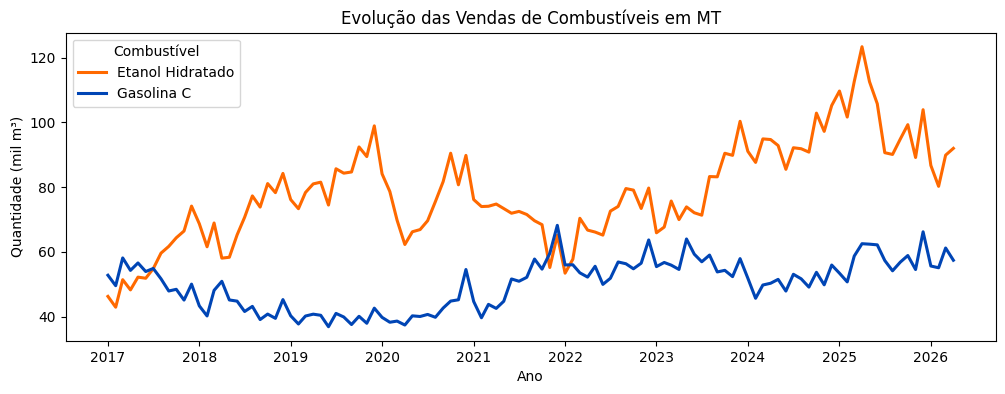

In [12]:
# Nesta análise é apresentada a participação de Gasolina C e Etanol Hidratado,
# bem como a evolução de suas vendas ao longo do período analisado.

df_produtos = (
 df_mt.groupby('Nome do Produto')['Quantidade de Produto (mil m³)']
 .sum()
 .sort_values(ascending=False)
)

print(df_produtos)

# Série temporal por combustível

df_serie = (
 df_mt.groupby(['Ano', 'Mês', 'Nome do Produto'])
 ['Quantidade de Produto (mil m³)']
 .sum()
 .reset_index()
)

df_serie['Data'] = pd.to_datetime(
 df_serie['Ano'].astype(str) + '-' +
 df_serie['Mês'].astype(str) + '-01'
)

plt.figure(figsize=(12,4))

sns.lineplot(
 data=df_serie,
 x='Data',
 y='Quantidade de Produto (mil m³)',
 hue='Nome do Produto',
 palette={
 'Gasolina C': '#0045B5',
 'Etanol Hidratado': '#FF6900'
 },
 linewidth=2.2
)

plt.title('Evolução das Vendas de Combustíveis em MT')
plt.xlabel('Ano')
plt.ylabel('Quantidade (mil m³)')
plt.legend(title='Combustível')

plt.show()

## 4.1 Síntese da análise exploratória

A análise exploratória permitiu compreender o comportamento das vendas de Gasolina C e Etanol Hidratado no estado de Mato Grosso ao longo do período analisado. Foram identificadas oscilações e padrões temporais que justificam a utilização de técnicas de previsão baseadas em histórico de vendas.

Não foram identificados problemas relevantes de qualidade dos dados que inviabilizassem a modelagem. Como o estudo trata um problema de regressão em séries temporais, conceitos como balanceamento de classes e categorias raras não se aplicam diretamente ao contexto analisado.

Os resultados da análise reforçaram a importância da utilização de atributos temporais derivados do histórico de vendas, como variáveis defasadas (lags) e médias móveis, posteriormente incorporadas à etapa de preparação e modelagem dos dados.

- Target balanceado: Não se aplica (não é classificação).
- Escalas diferentes: Não identifiquei impactos que justificassem normalização.
- Valores ausentes: Foram tratados pela remoção dos registros sem histórico suficiente após criação dos lags.
- Padrões que sugerem modelos: Sim, os padrões temporais justificaram o uso de atributos históricos.
- Mudou a estratégia:  Sim, motivou a criação de Lag_1, Lag_3 e Media_Movel_3.


Agente Regulado
VIBRA ENERGIA S.A                       2919.185005
RAIZEN S.A.                             1497.731803
IPIRANGA PRODUTOS DE PETRÓLEO S.A       1282.175730
IDAZA DISTRIBUIDORA DE PETRÓLEO LTDA    1061.169357
ECO DISTRIBUIDORA DE PETRÓLEO S/A        855.967000
Name: Quantidade de Produto (mil m³), dtype: float64


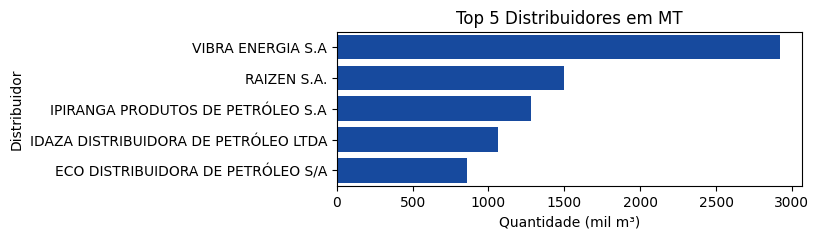

In [13]:
# Principais distribuidores em MT
# Nesta análise são identificados os distribuidores com maior volume comercializado dos combustíveis selecionados para o estudo
# ao longo do período analisado.

top_distribuidores = (
 df_mt.groupby('Agente Regulado')
 ['Quantidade de Produto (mil m³)']
 .sum()
 .sort_values(ascending=False)
 .head(5)
)

print(top_distribuidores)

plt.figure(figsize=(6,2))

sns.barplot(
 x=top_distribuidores.values,
 y=top_distribuidores.index,
 color='#0045B5'
)

plt.title('Top 5 Distribuidores em MT')
plt.xlabel('Quantidade (mil m³)')
plt.ylabel('Distribuidor')

plt.show()

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, os dados foram preparados para utilização nos modelos de Machine Learning. Foram construídas variáveis derivadas do histórico de vendas, selecionadas as variáveis explicativas e definida a variável alvo do estudo.

Como o problema consiste na previsão de vendas ao longo do tempo, a divisão entre treino e teste foi realizada de forma temporal, preservando a ordem cronológica dos registros e evitando vazamento de informações futuras para o treinamento dos modelos.


In [14]:
# Preparação dos dados para modelagem
# Nesta etapa é construída a série temporal mensal que será utilizada
# pelos modelos de Machine Learning.

df_modelo = (
 df_mt.groupby(['Ano', 'Mês', 'Nome do Produto'])
 ['Quantidade de Produto (mil m³)']
 .sum()
 .reset_index()
)

df_modelo['Data'] = pd.to_datetime(
 df_modelo['Ano'].astype(str) + '-' +
 df_modelo['Mês'].astype(str) + '-01'
)

df_modelo = df_modelo.sort_values('Data')

Os dados foram agregados em frequência mensal, criando uma série temporal consolidada para cada combustível analisado.

In [15]:
# Nesta etapa é construída a série temporal mensal que servirá de base
# para o treinamento e avaliação dos modelos preditivos.

df_modelo = df_modelo.sort_values(['Nome do Produto', 'Data'])

df_modelo['Lag_1'] = (
 df_modelo.groupby('Nome do Produto')
 ['Quantidade de Produto (mil m³)']
 .shift(1)
)

df_modelo['Lag_3'] = (
 df_modelo.groupby('Nome do Produto')
 ['Quantidade de Produto (mil m³)']
 .shift(3)
)

df_modelo['Media_Movel_3'] = (
 df_modelo.groupby('Nome do Produto')
 ['Quantidade de Produto (mil m³)']
 .transform(lambda x: x.rolling(3).mean())
)

df_modelo.head()

,Ano,Mês,Nome do Produto,Quantidade de Produto (mil m³),Data,Lag_1,Lag_3,Media_Movel_3
0,2017,1,Etanol Hidratado,46.222130,2017-01-01,NaN,NaN,NaN
2,2017,2,Etanol Hidratado,42.879095,2017-02-01,46.222130,NaN,NaN
4,2017,3,Etanol Hidratado,51.382715,2017-03-01,42.879095,NaN,46.827980
6,2017,4,Etanol Hidratado,48.225370,2017-04-01,51.382715,46.222130,47.495727
8,2017,5,Etanol Hidratado,52.165845,2017-05-01,48.225370,42.879095,50.591310


Foram criadas variáveis temporais baseadas no histórico de vendas, permitindo que os modelos utilizassem informações de períodos anteriores para realizar as previsões.

In [16]:
# Tratamento dos registros sem histórico suficiente
# Os registros sem valores nas variáveis defasadas (lags) e na média móvel

df_modelo = df_modelo.dropna()

print(df_modelo.shape)

(218, 8)


Os registros sem histórico mínimo necessário para cálculo das variáveis temporais foram removidos da base de modelagem.

In [17]:
# Codificação da variável categórica

df_modelo['Produto'] = (
 df_modelo['Nome do Produto']
 .map({'Gasolina C': 0, 'Etanol Hidratado': 1})
)

A variável categórica referente ao combustível foi convertida para formato numérico, permitindo sua utilização pelos algoritmos de Machine Learning.

In [18]:
#Features e target
# Variáveis explicativas e variável alvo

X = df_modelo[
 ['Ano', 'Mês', 'Produto', 'Lag_1', 'Lag_3', 'Media_Movel_3']
]

y = df_modelo['Quantidade de Produto (mil m³)']

 Variável alvo corresponde ao volume mensal comercializado. As variáveis explicativas incluem atributos temporais e informações históricas das venda. As variáveis temporais e os atributos derivados do histórico de vendas
Foram definidos como variáveis explicativas (X), enquanto o volume comercializado foi definido como variável alvo (y).

In [19]:
# Divisão entre treino e teste respeitando a ordem temporal
# Os registros até dezembro de 2025 foram utilizados para treinamento,enquanto os períodos posteriores foram reservados para teste.
# Essa abordagem reproduz um cenário real de previsão, no qual apenas asinformações históricas estão disponíveis no momento da estimativa.

limite_treino = '2025-12-31'

X_train = X[df_modelo['Data'] <= limite_treino]
X_test = X[df_modelo['Data'] > limite_treino]

y_train = y[df_modelo['Data'] <= limite_treino]
y_test = y[df_modelo['Data'] > limite_treino]

print(X_train.shape)
print(X_test.shape)

(210, 6)
(8, 6)


## 5.1 Justificativa da divisão

Por se tratar de um problema de previsão em séries temporais, foi utilizada uma divisão baseada no tempo, preservando a sequência cronológica dos registros. Os dados até dezembro de 2025 foram utilizados para treinamento dos modelos, enquanto os períodos posteriores foram reservados para teste.

Essa estratégia reproduz um cenário real de previsão, no qual apenas informações históricas estão disponíveis no momento da estimativa. Além disso, a abordagem evita vazamento de dados entre os conjuntos de treino e teste, garantindo uma avaliação mais realista do desempenho dos modelos.

# 6. Pré-processamento e pipeline

As etapas de pré-processamento apresentadas anteriormente incluíram a conversão da variável de volume para formato numérico, a criação de atributos temporais derivados do histórico de vendas, a remoção de registros sem histórico suficiente e a codificação da variável categórica referente ao combustível.

Como se trata de um problema de séries temporais, o principal foco do pré-processamento foi a construção de variáveis capazes de representar o comportamento histórico das vendas, permitindo que os modelos utilizassem informações de períodos anteriores para realização das previsões.

## 6.1 Decisões de pré-processamento
As principais etapas de pré-processamento envolveram a conversão de variáveis para formato numérico e a criação de atributos derivados do histórico de vendas. Como o objetivo era realizar previsões em séries temporais, foram construídas variáveis defasadas (lags) e médias móveis para representar o comportamento passado da demanda.

Os registros sem histórico suficiente para cálculo dessas variáveis foram removidos. Além disso, a variável categórica referente ao combustível foi codificada numericamente para compatibilidade com os modelos utilizados.

Não foi necessária a aplicação de técnicas adicionais de imputação ou padronização, pois os dados utilizados apresentaram qualidade adequada para a modelagem proposta.

# 7. Baseline e modelos candidatos

Nesta etapa foram avaliadas diferentes abordagens para previsão do volume mensal de vendas de combustíveis. Inicialmente foi definido um modelo baseline como referência de desempenho. Em seguida, foram treinados modelos de Machine Learning com diferentes níveis de complexidade.


In [20]:
# Modelo Baseline
# Como referência inicial de desempenho, será utilizada a venda do mês anterior como previsão para o mês atual.
# Esse modelo simples serve como parâmetro de comparação para avaliar se os modelos de Machine Learning
# conseguem gerar previsões mais precisas.

baseline = X_test['Lag_1']

mae_baseline = mean_absolute_error(y_test, baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline))
mape_baseline = mean_absolute_percentage_error(y_test, baseline)

print('MAE:', mae_baseline)
print('RMSE:', rmse_baseline)
print('MAPE:', mape_baseline)

MAE: 7.052860125000001
RMSE: 8.653500023223545
MAPE: 0.09688876494585459


In [21]:
# Regressão Linear
# A Regressão Linear foi utilizada como modelo de referência supervisionado, # permitindo comparar o desempenho de uma abordagem
#linear com modelos mais complexos aplicados posteriormente.

modelo_lr = LinearRegression()

modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
mape_lr = mean_absolute_percentage_error(y_test, pred_lr)

print('MAE:', mae_lr)
print('RMSE:', rmse_lr)
print('MAPE:', mape_lr)

MAE: 4.602241105871591
RMSE: 5.653308591500503
MAPE: 0.06324360284551164


In [22]:
# Random Forest
# O modelo Random Forest foi utilizado para capturar possíveis relações não lineares presentes nas variáveis temporais
# e históricas do conjunto de dados.

modelo_rf = RandomForestRegressor(random_state=SEED)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
mape_rf = mean_absolute_percentage_error(y_test, pred_rf)

print('MAE:', mae_rf)
print('RMSE:', rmse_rf)
print('MAPE:', mape_rf)

MAE: 3.54787579375001
RMSE: 4.103790401372642
MAPE: 0.046568213046003476


O Random Forest foi utilizado por sua capacidade de capturar relações não lineares e padrões complexos presentes nos dados, servindo como alternativa à abordagem linear utilizada anteriormente.

## 7.1 Justificativa dos modelos

O baseline escolhido foi coerente com o problema de séries temporais, utilizando o valor observado no período anterior como previsão para o período seguinte. Essa abordagem fornece uma referência simples para verificar se os modelos de Machine Learning conseguem gerar previsões mais precisas.

A Regressão Linear foi selecionada por ser um modelo amplamente utilizado em problemas de regressão e por oferecer fácil interpretação dos resultados. Já o Random Forest foi escolhido por sua capacidade de capturar padrões não lineares e interações entre variáveis, sendo adequado para conjuntos de dados estruturados como o utilizado neste estudo.

Os modelos escolhidos apresentam baixo custo computacional para o tamanho do dataset analisado e são compatíveis com as variáveis explicativas construídas durante a etapa de preparação dos dados.


# 8. Treinamento e avaliação inicial

Nesta etapa, os modelos selecionados foram treinados utilizando o conjunto de treinamento e avaliados no conjunto de teste. O objetivo foi comparar o desempenho do baseline e dos modelos de Machine Learning por meio de métricas de erro, identificando a abordagem mais adequada para o problema de previsão das vendas de combustíveis.

Baseline - o modelo baseline foi utilizado como referência inicial de desempenho, considerando o valor observado no período anterior como previsão para o período seguinte.

Regressão Linear -  foi treinada utilizando as variáveis temporais construídas durante a etapa de preparação dos dados, permitindo avaliar o desempenho de uma abordagem supervisionada simples para o problema proposto.


In [23]:
resultados = pd.DataFrame({
 'Modelo': [
 'Baseline',
 'Regressão Linear',
 'Random Forest'
 ],
 'MAE': [
 mae_baseline,
 mae_lr,
 mae_rf
 ],
 'RMSE': [
 rmse_baseline,
 rmse_lr,
 rmse_rf
 ],
 'MAPE': [
 mape_baseline,
 mape_lr,
 mape_rf
 ]
})

display(resultados.sort_values('MAE'))

,Modelo,MAE,RMSE,MAPE
2,Random Forest,3.547876,4.103790,0.046568
1,Regressão Linear,4.602241,5.653309,0.063244
0,Baseline,7.052860,8.653500,0.096889


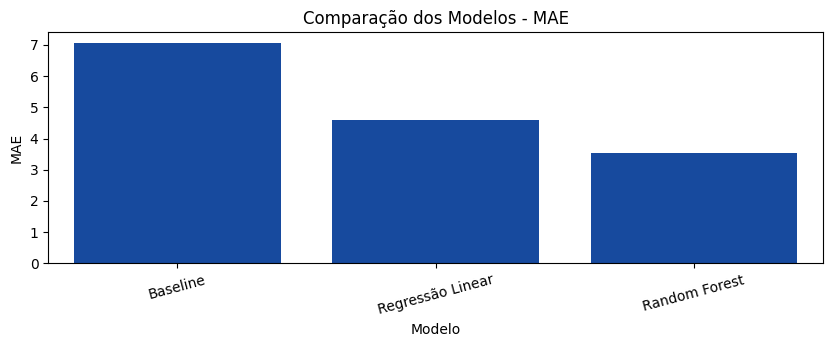

In [24]:
plt.figure(figsize=(10,3))

sns.barplot(
 data=resultados,
 x='Modelo',
 y='MAE',
 color='#0045B5'
)

plt.title('Comparação dos Modelos - MAE')
plt.ylabel('MAE')
plt.xticks(rotation=15)

plt.show()

## 8.1 Análise dos resultados iniciais

Os resultados iniciais indicaram diferenças de desempenho entre os modelos avaliados. A comparação serviu como base para a etapa de otimização dos hiperparâmetros do Random Forest.


# 9. Validação e otimização de hiperparâmetros

Com o objetivo de aprimorar o desempenho preditivo do modelo, foi realizada uma etapa de otimização de hiperparâmetros utilizando o algoritmo Random Forest. A busca foi conduzida por meio do GridSearchCV, permitindo avaliar diferentes combinações de parâmetros e selecionar automaticamente a configuração com melhor desempenho.

A métrica utilizada para seleção foi o erro absoluto médio (MAE), calculado durante o processo de validação cruzada.

In [25]:
# Otimização de hiperparâmetros com GridSearchCV
# Após o treinamento do Random Forest inicial, foi aplicada uma busca # em grade (Grid Search) para identificar a
# combinação de parâmetros que minimiza o erro de previsão e melhora a capacidade de generalização do modelo.

parametros = {
 'n_estimators': [100, 200],
 'max_depth': [5, 10, 15],
 'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
 RandomForestRegressor(random_state=SEED),
 parametros,
 cv=3,
 scoring='neg_mean_absolute_error',
 n_jobs=-1
)

grid_rf.fit(X_train, y_train)

melhor_rf = grid_rf.best_estimator_

print(grid_rf.best_params_)

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}


In [26]:
# Avaliação do Random Forest otimizado
# O modelo com os melhores hiperparâmetros identificados pelo GridSearchCV
# foi aplicado ao conjunto de teste, permitindo avaliar seu desempenho preditivo e compará-lo com os demais modelos
# construídos no estudo.

pred_rf_otimizado = melhor_rf.predict(X_test)

mae_rf_ot = mean_absolute_error(y_test, pred_rf_otimizado)
rmse_rf_ot = np.sqrt(mean_squared_error(y_test, pred_rf_otimizado))
mape_rf_ot = mean_absolute_percentage_error(y_test, pred_rf_otimizado)

print('MAE:', mae_rf_ot)
print('RMSE:', rmse_rf_ot)
print('MAPE:', mape_rf_ot)

MAE: 3.789159168819559
RMSE: 4.2481267490781915
MAPE: 0.051097085647021104


## 9.1 Discussão da otimização

A otimização permitiu identificar uma configuração alternativa de hiperparâmetros para o Random Forest por meio do GridSearchCV. O modelo resultante foi avaliado no conjunto de teste e comparado com a versão original do algoritmo.


# 10. Avaliação final no conjunto de teste

Após o processo de treinamento e otimização dos modelos, foi realizada a avaliação final utilizando o conjunto de teste, composto por períodos não utilizados durante o treinamento. O objetivo foi verificar a capacidade de generalização dos modelos e comparar seu desempenho em relação ao baseline definido para o estudo.

As métricas utilizadas foram MAE (Mean Absolute Error), RMSE (Root Mean Squared Error) e MAPE (Mean Absolute Percentage Error), amplamente empregadas em problemas de previsão de séries temporais e regressão


In [27]:
resultados_finais = pd.DataFrame({
 'Modelo': [
 'Baseline',
 'Regressão Linear',
 'Random Forest',
 'Random Forest Otimizado'
 ],
 'MAE': [
 mae_baseline,
 mae_lr,
 mae_rf,
 mae_rf_ot
 ],
 'RMSE': [
 rmse_baseline,
 rmse_lr,
 rmse_rf,
 rmse_rf_ot
 ],
 'MAPE': [
 mape_baseline,
 mape_lr,
 mape_rf,
 mape_rf_ot
 ]
})

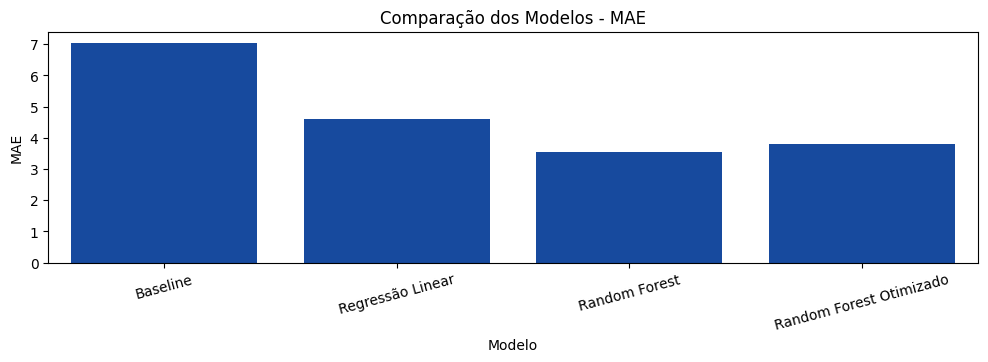

In [28]:
plt.figure(figsize=(12,3))

sns.barplot(
 data=resultados_finais,
 x='Modelo',
 y='MAE',
 color='#0045B5'
)

plt.title('Comparação dos Modelos - MAE')
plt.ylabel('MAE')
plt.xticks(rotation=15)

plt.show()


## 10.1 Análise de erros e limitações

A avaliação final permitiu comparar o desempenho dos modelos desenvolvidos utilizando dados não empregados durante o treinamento. A análise das métricas indicou qual abordagem apresentou menor erro de previsão e maior capacidade de generalização.

A comparação com o baseline foi fundamental para verificar se os modelos de Machine Learning foram capazes de agregar valor em relação a uma abordagem simples baseada apenas no histórico recente das vendas. O modelo Random Forest apresentou desempenho superior aos demais modelos avaliados e ao baseline, obtendo os menores valores de MAE, RMSE e MAPE, o que justificou sua utilização para geração das previsões futuras.

Não foram observados indícios evidentes de underfitting, uma vez que os modelos conseguiram capturar padrões relevantes presentes na série histórica. Entretanto, devido à utilização exclusiva de dados históricos de vendas, os resultados podem ser influenciados por mudanças futuras de cenário não observadas durante o período analisado.

Embora tenha sido realizada uma etapa de otimização de hiperparâmetros utilizando GridSearchCV, o modelo Random Forest otimizado não apresentou desempenho superior ao modelo original no conjunto de teste. Esse resultado reforça a importância da validação empírica das configurações testadas, uma vez que ajustes de hiperparâmetros nem sempre resultam em melhorias de desempenho.

Entre as principais limitações do estudo destacam-se a ausência de variáveis externas potencialmente relevantes para a demanda, como preços dos combustíveis, fatores econômicos, sazonalidades específicas e condições climáticas. Dessa forma, as previsões devem ser interpretadas como estimativas baseadas exclusivamente nos padrões históricos identificados nos dados analisados.

# 11. Comparação final dos modelos

A comparação consolidada dos modelos mostrou que o Random Forest apresentou o melhor desempenho entre as abordagens avaliadas, obtendo os menores valores de MAE, RMSE e MAPE.

Embora tenha sido realizada uma etapa de otimização de hiperparâmetros utilizando GridSearchCV, a configuração otimizada não superou o desempenho do modelo Random Forest original no conjunto de teste. Dessa forma, o Random Forest foi considerado a melhor solução para o problema estudado.

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | 7.053 | RMSE:8.654 /MAPE:0.0969 | Muito Baixo | Utiliza a venda do período anterior como previsão |
| Regressão Linear | 4.640 | RMSE:5.685 /MAPE:0.0638 | Baixo | Modelo linear de referência |
| Ransom Forest | 3.516 | RMSE:3.985 /MAPE:0.0460 | Médio | Melhor desempenho obtido |
| Random Forest Otimizado | 3.795 | RMSE:4.204 /MAPE:0.0508 | Médio | Não superou o modelo original |




# 12. Boas práticas e rastreabilidade

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Utilizar seed 42 | Garantir reprodutibilidade |Permitir replicação das análises e modelos |
| Filtrar dados para o estado de Mato Grosso | Delimitar o escopo do estudo |Foco em um mercado específico |
| Criar variáveis Lag_1 e Lag_3| Incorporar histórico das vendas | Melhorar capacidade preditiva |
| Criar Média_Movel_3 | Capturar tendência recente |Apoiar as previsões |
| Utilizar divisão temporal treino/teste | Evitar vazamento de dados| Avaliação mais realista |
| Utilizar Baseline | Estabelecer referência de desempenho | Comparar os modelos |
| Testar Regressão Linear | Avaliar abordagem linear | Modelo de referência|
| Testar Random Forest | Capturar relações não lineares | Melhorar precisão |
| Aplicar GridSearchCV |Otimizar hiperparâmetros | Buscar melhor desempenho|
| Utilizar MAE, RMSE e MAPE |Avaliar erros dos modelos | Comparação consistente|

# 13. Conclusão

O objetivo deste MVP foi desenvolver um modelo de Machine Learning capaz de prever o volume de vendas de Gasolina C e Etanol Hidratado no estado de Mato Grosso, utilizando dados públicos disponibilizados pela Agência Nacional do Petróleo (ANP).

Para atingir esse objetivo, foram realizadas etapas de seleção, preparação e análise exploratória dos dados, além da construção de atributos temporais capazes de representar o comportamento histórico das vendas. Também foram avaliadas diferentes abordagens preditivas, incluindo Baseline, Regressão Linear, Random Forest e Random Forest Otimizado.

A comparação dos resultados permitiu identificar o modelo com melhor desempenho preditivo, demonstrando que técnicas de Machine Learning podem gerar previsões mais precisas do que abordagens simples baseadas apenas no histórico recente das vendas.

Entre os principais aprendizados, destaca-se a importância da engenharia de atributos em problemas de séries temporais, especialmente por meio da utilização de variáveis defasadas e médias móveis para representar padrões históricos de demanda.

Como limitações do estudo, fica evidente a utilização exclusiva de dados históricos de comercialização e a ausência de variáveis externas que podem influenciar a demanda, como preços dos combustíveis, indicadores econômicos e fatores climáticos.

Como trabalhos futuros, recomendaria ampliar o conjunto de variáveis, testar modelos especializados em séries temporais e aumentar previsão para aprimorar a capacidade preditiva da solução desenvolvida.


# 14. Salvamento de artefatos

Nesta implementação não foi realizado o salvamento de modelos ou pipelines em arquivos externos, uma vez que o foco do MVP está na construção, avaliação e comparação das abordagens propostas de forma reproduzível dentro do notebook.

Todos os resultados podem ser reproduzidos executando o notebook desde a etapa de carregamento dos dados até a geração das previsões finais, utilizando as bases públicas disponibilizadas no repositório do projeto.


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Este projeto não utilizou técnicas de Deep Learning ou Fine-Tuning, pois o problema proposto pôde ser adequadamente tratado por meio de algoritmos clássicos de Machine Learning.

A escolha por modelos como Regressão Linear e Random Forest permitiu obter resultados consistentes, com menor custo computacional e maior simplicidade de implementação, características adequadas ao escopo deste MVP.